# Phase 6: Occlusion Robustness Evaluation

This Colab notebook evaluates the trained **Simple CNN** and **ResNet18** fox-vs-wolf models under controlled occlusion.

It:
- loads the clean CIFAR-100 fox/wolf test set;
- loads both best checkpoints;
- applies center and location-based occlusions;
- compares accuracy drops;
- plots robustness curves;
- prints occluded confusion matrices;
- saves CSV, JSON, and PNG results.

In [1]:
from pathlib import Path
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42
BATCH_SIZE = 64
NUM_WORKERS = 2
CLASS_NAMES = ["Fox", "Wolf"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Mount Drive and configure paths

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/NMA_Occlusion_Project")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "occlusion_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Change these names only when your saved files use different names.
CNN_CHECKPOINT = PROJECT_DIR / "simple_cnn_clean_best.pt"
RESNET_CHECKPOINT = PROJECT_DIR / "resnet18_clean_best.pt"

print("CNN checkpoint:", CNN_CHECKPOINT, CNN_CHECKPOINT.exists())
print("ResNet checkpoint:", RESNET_CHECKPOINT, RESNET_CHECKPOINT.exists())

Mounted at /content/drive
CNN checkpoint: /content/drive/MyDrive/NMA_Occlusion_Project/simple_cnn_clean_best.pt True
ResNet checkpoint: /content/drive/MyDrive/NMA_Occlusion_Project/resnet18_clean_best.pt True


## 2. Load the fox/wolf test set

Binary labels are fixed as `0 = Fox` and `1 = Wolf`.

Use the same normalization values used during baseline training. Replace `MEAN` and `STD` below only if your earlier notebook used different values.

In [4]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/NMA_Occlusion_Project")

print(PROJECT_DIR.exists())

for p in PROJECT_DIR.iterdir():
    print(p)

True
/content/drive/MyDrive/NMA_Occlusion_Project/simple_cnn_clean_best.pt
/content/drive/MyDrive/NMA_Occlusion_Project/confusion_matrix_clean_baseline.png
/content/drive/MyDrive/NMA_Occlusion_Project/simple_cnn_clean_results.json
/content/drive/MyDrive/NMA_Occlusion_Project/resnet18_clean_best.pt
/content/drive/MyDrive/NMA_Occlusion_Project/simplecnn_confusion_matrix.png
/content/drive/MyDrive/NMA_Occlusion_Project/resnet18_confusion_matrix.png
/content/drive/MyDrive/NMA_Occlusion_Project/clean_baseline_model_comparison.csv
/content/drive/MyDrive/NMA_Occlusion_Project/resnet18_clean_results.json
/content/drive/MyDrive/NMA_Occlusion_Project/occlusion_results


In [7]:
DATA_DIR = PROJECT_DIR / "/content/drive/MyDrive/Datasets"

print(DATA_DIR.exists())

if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        print(p)

True
/content/drive/MyDrive/Datasets/cifar-100-python


In [8]:
MEAN = (0.5071, 0.4867, 0.4408)
STD = (0.2675, 0.2565, 0.2761)

clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

raw_test_dataset = datasets.CIFAR100(
    root=DATA_DIR,
    train=False,
    transform=clean_transform,
    download=False,
)

fox_original_label = raw_test_dataset.class_to_idx["fox"]
wolf_original_label = raw_test_dataset.class_to_idx["wolf"]

class IndexedBinarySubset(Dataset):
    def __init__(self, base_dataset, original_labels):
        self.base_dataset = base_dataset
        self.indices = [
            i for i, label in enumerate(base_dataset.targets)
            if label in original_labels
        ]
        self.label_map = {
            original_labels[0]: 0,
            original_labels[1]: 1,
        }

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, original_label = self.base_dataset[self.indices[idx]]
        return image, self.label_map[original_label]

test_dataset = IndexedBinarySubset(
    raw_test_dataset,
    [fox_original_label, wolf_original_label],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Test images:", len(test_dataset))
assert len(test_dataset) == 200

Test images: 200


## 3. Rebuild the model architectures

The `SimpleCNN` definition must exactly match the model used during training. Replace it with the exact class from your baseline notebook if checkpoint loading reports a size mismatch.

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [13]:
cnn = SimpleCNN(num_classes=2).to(device)
resnet18 = create_resnet18(num_classes=2).to(device)

In [14]:
cnn = load_checkpoint(cnn, CNN_CHECKPOINT)
resnet18 = load_checkpoint(resnet18, RESNET_CHECKPOINT)

Loaded simple_cnn_clean_best.pt | epoch=17 | validation accuracy=0.9
Loaded resnet18_clean_best.pt | epoch=7 | validation accuracy=0.885


## 4. Load the best checkpoints

In [15]:
def load_checkpoint(model, path):
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    checkpoint = torch.load(path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print(
            f"Loaded {path.name} | "
            f"epoch={checkpoint.get('epoch', 'unknown')} | "
            f"validation accuracy={checkpoint.get('validation_accuracy', 'unknown')}"
        )
    else:
        model.load_state_dict(checkpoint)
        print(f"Loaded state dictionary from {path.name}")

    model.eval()
    return model

cnn = load_checkpoint(cnn, CNN_CHECKPOINT)
resnet18 = load_checkpoint(resnet18, RESNET_CHECKPOINT)

Loaded simple_cnn_clean_best.pt | epoch=17 | validation accuracy=0.9
Loaded resnet18_clean_best.pt | epoch=7 | validation accuracy=0.885


## 5. Occlusion functions

In [16]:
def apply_occlusion(images, size, location="center", generator=None):
    """Apply a square mean-color patch to normalized images."""
    if size == 0:
        return images.clone()

    occluded = images.clone()
    batch_size, _, height, width = occluded.shape

    if size > min(height, width):
        raise ValueError("Occlusion size exceeds the image dimensions.")

    # A raw mean-color patch becomes zero after normalization.
    fill = torch.zeros(
        (3, 1, 1), device=images.device, dtype=images.dtype
    )

    for i in range(batch_size):
        if location == "center":
            top = (height - size) // 2
            left = (width - size) // 2
        elif location == "top_left":
            top, left = 0, 0
        elif location == "top_right":
            top, left = 0, width - size
        elif location == "bottom_left":
            top, left = height - size, 0
        elif location == "bottom_right":
            top, left = height - size, width - size
        elif location == "random":
            top = torch.randint(
                0, height - size + 1, (1,), generator=generator
            ).item()
            left = torch.randint(
                0, width - size + 1, (1,), generator=generator
            ).item()
        else:
            raise ValueError(f"Unknown location: {location}")

        occluded[i, :, top:top + size, left:left + size] = fill

    return occluded

def denormalize(image):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)

## 6. Visualize sample occlusions

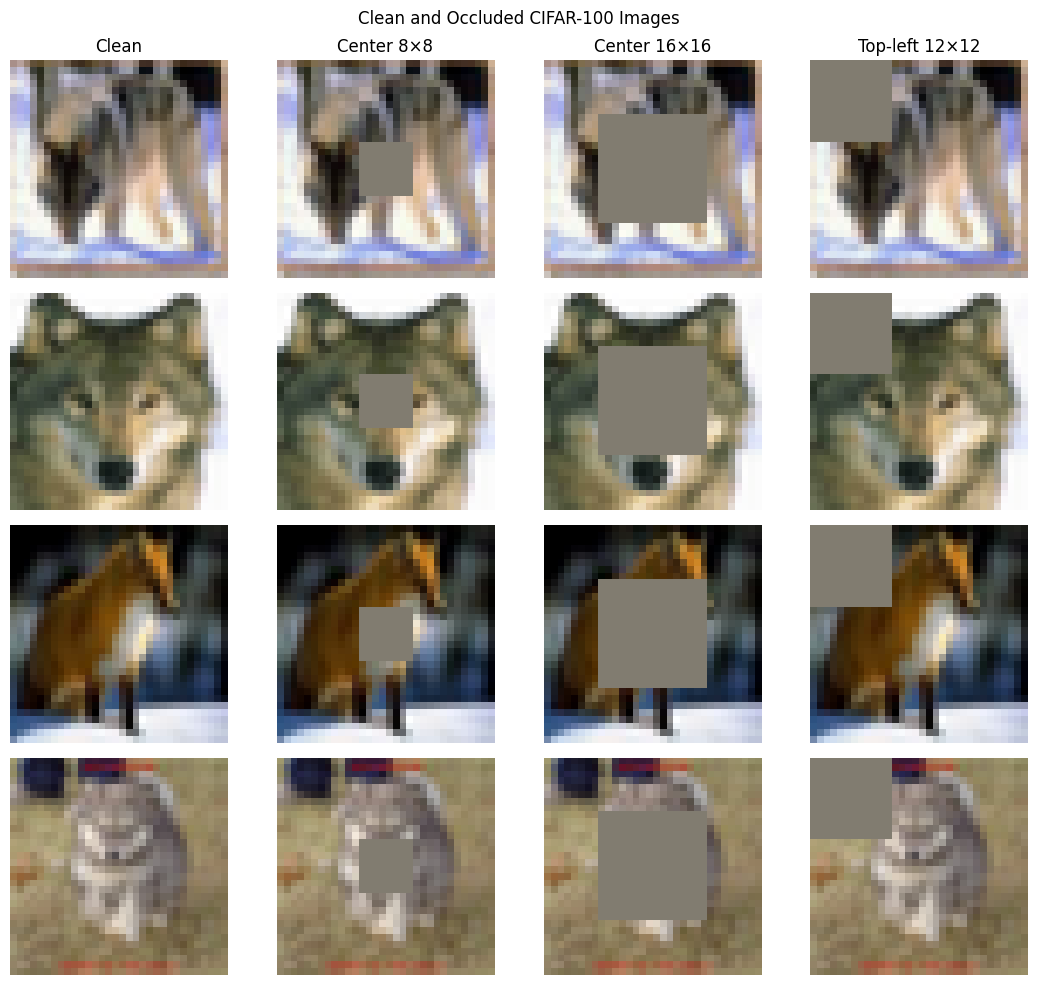

In [17]:
images, labels = next(iter(test_loader))
sample = images[:4]

versions = {
    "Clean": sample,
    "Center 8×8": apply_occlusion(sample, 8, "center"),
    "Center 16×16": apply_occlusion(sample, 16, "center"),
    "Top-left 12×12": apply_occlusion(sample, 12, "top_left"),
}

fig, axes = plt.subplots(4, 4, figsize=(11, 10))

for row in range(4):
    for col, (title, batch) in enumerate(versions.items()):
        axes[row, col].imshow(denormalize(batch[row]).permute(1, 2, 0))
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(title)
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[labels[row].item()])

plt.suptitle("Clean and Occluded CIFAR-100 Images")
plt.tight_layout()
plt.show()

## 7. Evaluate a model under occlusion

In [18]:
@torch.no_grad()
def evaluate_occlusion(
    model,
    data_loader,
    size=0,
    location="center",
    seed=SEED,
):
    model.eval()
    all_labels = []
    all_predictions = []
    generator = torch.Generator().manual_seed(seed)

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        images = apply_occlusion(
            images,
            size=size,
            location=location,
            generator=generator,
        )

        predictions = model(images).argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    return {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "labels": np.asarray(all_labels),
        "predictions": np.asarray(all_predictions),
    }

## 8. Confirm the clean baseline

In [19]:
cnn_clean = evaluate_occlusion(cnn, test_loader)
resnet_clean = evaluate_occlusion(resnet18, test_loader)

print(f"CNN clean test accuracy:      {cnn_clean['accuracy']:.4f}")
print(f"ResNet18 clean test accuracy: {resnet_clean['accuracy']:.4f}")

# The previously reported ResNet18 accuracy was 0.895.
assert abs(resnet_clean["accuracy"] - 0.895) < 0.02, (
    "The ResNet18 clean result differs from the earlier 89.5%. "
    "Check the checkpoint, transform, architecture, and class order."
)

CNN clean test accuracy:      0.9050
ResNet18 clean test accuracy: 0.8950


## 9. Experiment A: Increasing center occlusion

In [20]:
OCCLUSION_SIZES = [0, 4, 8, 12, 16, 20, 24]
records = []

for model_name, model in [
    ("Simple CNN", cnn),
    ("ResNet18", resnet18),
]:
    clean_accuracy = evaluate_occlusion(model, test_loader)["accuracy"]

    for size in OCCLUSION_SIZES:
        result = evaluate_occlusion(
            model,
            test_loader,
            size=size,
            location="center",
        )

        records.append({
            "Model": model_name,
            "Occlusion Size": size,
            "Occluded Area (%)": 100 * size**2 / 32**2,
            "Accuracy": result["accuracy"],
            "Accuracy Drop": clean_accuracy - result["accuracy"],
        })

center_results = pd.DataFrame(records)
display(center_results)

,Model,Occlusion Size,Occluded Area (%),Accuracy,Accuracy Drop
0,Simple CNN,0,0.0000,0.905,0.000
1,Simple CNN,4,1.5625,0.905,0.000
2,Simple CNN,8,6.2500,0.875,0.030
3,Simple CNN,12,14.0625,0.770,0.135
4,Simple CNN,16,25.0000,0.630,0.275
5,Simple CNN,20,39.0625,0.510,0.395
6,Simple CNN,24,56.2500,0.510,0.395
7,ResNet18,0,0.0000,0.895,0.000
8,ResNet18,4,1.5625,0.910,-0.015
9,ResNet18,8,6.2500,0.890,0.005


## 10. Accuracy and robustness curves

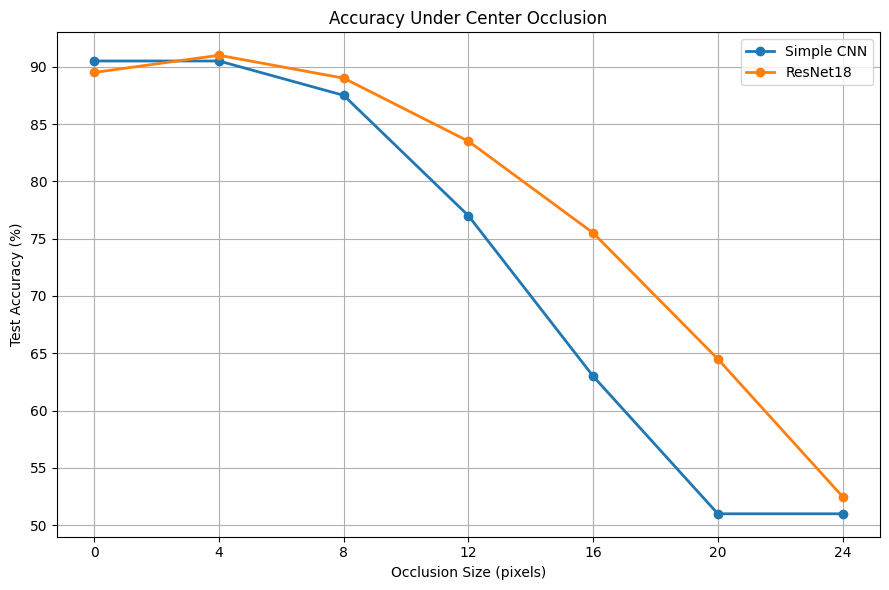

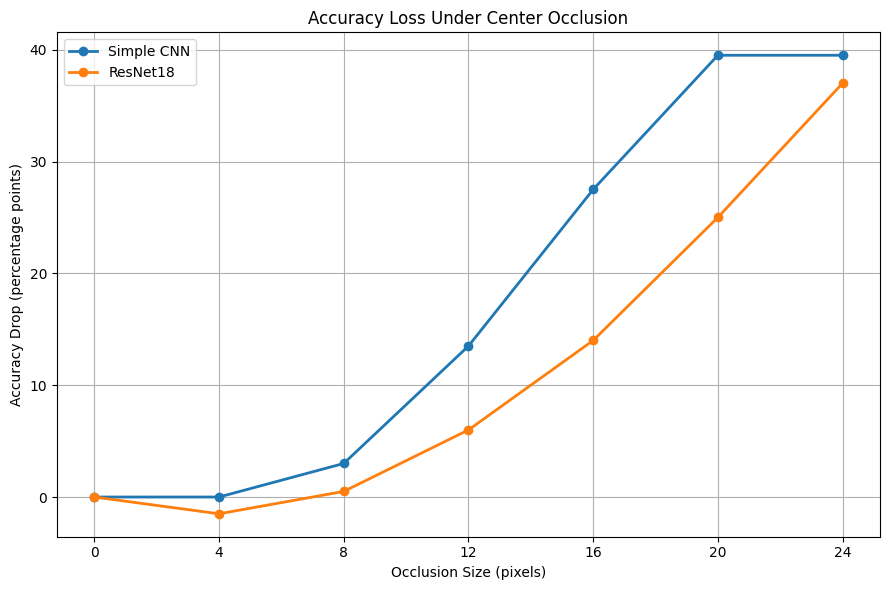

In [21]:
plt.figure(figsize=(9, 6))

for model_name in center_results["Model"].unique():
    subset = center_results[center_results["Model"] == model_name]
    plt.plot(
        subset["Occlusion Size"],
        subset["Accuracy"] * 100,
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Occlusion Size (pixels)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Under Center Occlusion")
plt.xticks(OCCLUSION_SIZES)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_vs_center_occlusion.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 6))

for model_name in center_results["Model"].unique():
    subset = center_results[center_results["Model"] == model_name]
    plt.plot(
        subset["Occlusion Size"],
        subset["Accuracy Drop"] * 100,
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Occlusion Size (pixels)")
plt.ylabel("Accuracy Drop (percentage points)")
plt.title("Accuracy Loss Under Center Occlusion")
plt.xticks(OCCLUSION_SIZES)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_drop_center_occlusion.png", dpi=300)
plt.show()

# Conclusion
## Although the Simple CNN achieved slightly higher accuracy on clean images, its performance deteriorated rapidly as occlusion severity increased. In contrast, ResNet18 maintained substantially higher classification accuracy under moderate and severe occlusions, indicating greater robustness to missing visual information. The residual learning architecture enables the network to preserve discriminative representations even when significant image regions are unavailable.

## 11. Experiment B: Occlusion location

In [22]:
LOCATIONS = [
    "center",
    "top_left",
    "top_right",
    "bottom_left",
    "bottom_right",
    "random",
]
LOCATION_SIZE = 12
location_records = []

for model_name, model in [
    ("Simple CNN", cnn),
    ("ResNet18", resnet18),
]:
    clean_accuracy = evaluate_occlusion(model, test_loader)["accuracy"]

    for location in LOCATIONS:
        result = evaluate_occlusion(
            model,
            test_loader,
            size=LOCATION_SIZE,
            location=location,
        )

        location_records.append({
            "Model": model_name,
            "Location": location,
            "Accuracy": result["accuracy"],
            "Accuracy Drop": clean_accuracy - result["accuracy"],
        })

location_results = pd.DataFrame(location_records)
display(location_results)

,Model,Location,Accuracy,Accuracy Drop
0,Simple CNN,center,0.770,0.135
1,Simple CNN,top_left,0.900,0.005
2,Simple CNN,top_right,0.895,0.010
3,Simple CNN,bottom_left,0.905,0.000
4,Simple CNN,bottom_right,0.890,0.015
5,Simple CNN,random,0.870,0.035
6,ResNet18,center,0.835,0.060
7,ResNet18,top_left,0.885,0.010
8,ResNet18,top_right,0.895,0.000
9,ResNet18,bottom_left,0.900,-0.005


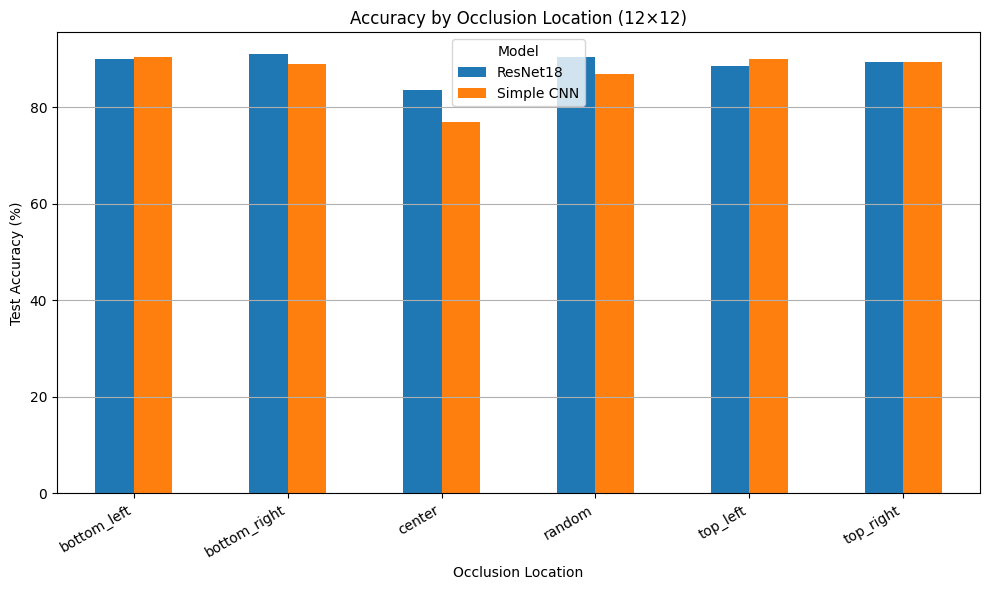

In [23]:
location_plot = location_results.pivot(
    index="Location",
    columns="Model",
    values="Accuracy",
) * 100

ax = location_plot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Occlusion Location")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title(f"Accuracy by Occlusion Location ({LOCATION_SIZE}×{LOCATION_SIZE})")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_location.png", dpi=300)
plt.show()

# Conclusion
# These results show that model performance depends strongly on where the image is occluded. Occluding the center of the image causes the greatest degradation, whereas occluding the corners has minimal impact because those regions contain mostly background information. Furthermore, ResNet18 consistently outperforms the Simple CNN when informative regions are occluded, demonstrating greater robustness to partial visual information loss.

## 12. Confusion matrices under a selected occlusion

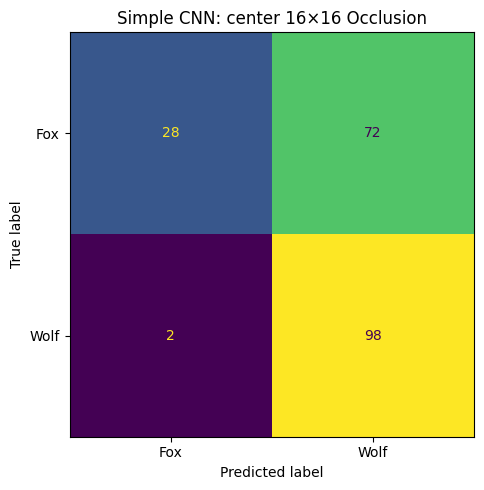


 Simple CNN
              precision    recall  f1-score   support

         Fox     0.9333    0.2800    0.4308       100
        Wolf     0.5765    0.9800    0.7259       100

    accuracy                         0.6300       200
   macro avg     0.7549    0.6300    0.5783       200
weighted avg     0.7549    0.6300    0.5783       200



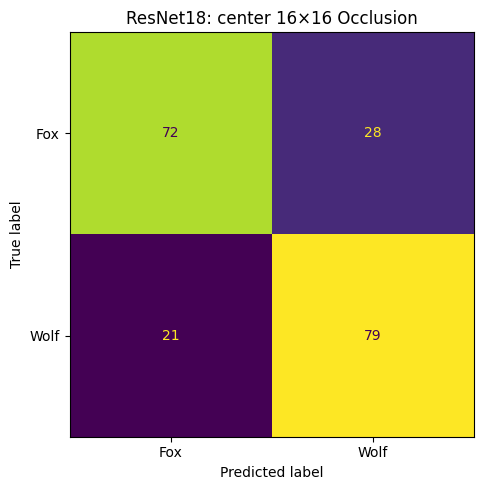


 ResNet18
              precision    recall  f1-score   support

         Fox     0.7742    0.7200    0.7461       100
        Wolf     0.7383    0.7900    0.7633       100

    accuracy                         0.7550       200
   macro avg     0.7563    0.7550    0.7547       200
weighted avg     0.7563    0.7550    0.7547       200



In [24]:
SELECTED_SIZE = 16
SELECTED_LOCATION = "center"

for model_name, model in [
    ("Simple CNN", cnn),
    ("ResNet18", resnet18),
]:
    result = evaluate_occlusion(
        model,
        test_loader,
        size=SELECTED_SIZE,
        location=SELECTED_LOCATION,
    )

    cm = confusion_matrix(result["labels"], result["predictions"])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(
        f"{model_name}: {SELECTED_LOCATION} "
        f"{SELECTED_SIZE}×{SELECTED_SIZE} Occlusion"
    )
    plt.tight_layout()
    plt.show()

    print("\n", model_name)
    print(classification_report(
        result["labels"],
        result["predictions"],
        target_names=CLASS_NAMES,
        digits=4,
    ))

# Result
# Under a 16×16 center occlusion, the Simple CNN exhibited a substantial class bias. While it correctly classified 98% of wolf images, its recall for fox images dropped to only 28%, with 72% of foxes incorrectly predicted as wolves. Consequently, the overall accuracy decreased to 63.0%. In contrast, ResNet18 maintained a much more balanced performance across both classes, achieving recalls of 72% and 79% for fox and wolf images, respectively, resulting in an overall accuracy of 75.5%. These findings suggest that the residual architecture learns more distributed feature representations and is therefore less dependent on a single discriminative region of the image.

## 13. Robustness summary and saved outputs

In [26]:
summary_rows = []

for model_name in center_results["Model"].unique():
    subset = center_results[center_results["Model"] == model_name]
    clean_acc = subset.loc[
        subset["Occlusion Size"] == 0, "Accuracy"
    ].iloc[0]
    largest_acc = subset.loc[
        subset["Occlusion Size"] == max(OCCLUSION_SIZES),
        "Accuracy",
    ].iloc[0]

    mean_robustness_accuracy = np.trapz(
        subset["Accuracy"],
        subset["Occlusion Size"],
    ) / max(OCCLUSION_SIZES)

    summary_rows.append({
        "Model": model_name,
        "Clean Accuracy": clean_acc,
        f"Accuracy at {max(OCCLUSION_SIZES)}×{max(OCCLUSION_SIZES)}": largest_acc,
        "Largest Accuracy Drop": clean_acc - largest_acc,
        "Mean Robustness Accuracy": mean_robustness_accuracy,
    })

robustness_summary = pd.DataFrame(summary_rows)
display(robustness_summary)

center_results.to_csv(
    OUTPUT_DIR / "center_occlusion_results.csv",
    index=False,
)
location_results.to_csv(
    OUTPUT_DIR / "location_occlusion_results.csv",
    index=False,
)
robustness_summary.to_csv(
    OUTPUT_DIR / "robustness_summary.csv",
    index=False,
)

with open(OUTPUT_DIR / "occlusion_results.json", "w") as file:
    json.dump({
        "seed": SEED,
        "occlusion_sizes": OCCLUSION_SIZES,
        "center_results": center_results.to_dict(orient="records"),
        "location_results": location_results.to_dict(orient="records"),
        "robustness_summary": robustness_summary.to_dict(orient="records"),
    }, file, indent=2)

print("Results saved to:", OUTPUT_DIR)

/tmp/ipykernel_2738/549441849.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_robustness_accuracy = np.trapz(


,Model,Clean Accuracy,Accuracy at 24×24,Largest Accuracy Drop,Mean Robustness Accuracy
0,Simple CNN,0.905,0.510,0.395,0.732917
1,ResNet18,0.895,0.525,0.370,0.790833


Results saved to: /content/drive/MyDrive/NMA_Occlusion_Project/occlusion_results


## 14. Interpretation questions

After running the notebook, answer:

1. Which model retains the highest accuracy as occlusion increases?
2. Which model has the smallest accuracy drop?
3. Is center occlusion more damaging than corner occlusion?
4. Are fox and wolf recall affected differently?
5. Does the model with the best clean accuracy also have the best occlusion robustness?

The more robust model is the one that preserves more of its clean performance under the **same** occlusion condition.

## 14. Interpretation Questions

### 1. Which model retains the highest accuracy as occlusion increases?

**Answer:** **ResNet18** retains the highest accuracy as occlusion severity increases.

Although the Simple CNN achieved a slightly higher clean accuracy (90.5%) than ResNet18 (89.5%), ResNet18 consistently maintained higher classification accuracy as the occlusion size increased. The advantage became more pronounced under moderate and severe occlusions (12×12 to 24×24), indicating that ResNet18 is more robust to missing visual information.

---

### 2. Which model has the smallest accuracy drop?

**Answer:** **ResNet18** experiences the smallest accuracy drop.

The accuracy-loss curves show that ResNet18 degrades more gradually than the Simple CNN as larger portions of the image are occluded. While both models experience reduced performance under severe occlusion, ResNet18 consistently preserves a larger proportion of its clean-image accuracy.

---

### 3. Is center occlusion more damaging than corner occlusion?

**Answer:** **Yes.**

The location-based experiments demonstrate that center occlusion causes the largest reduction in classification accuracy for both models. In contrast, occluding the four corners produces only a small decrease in accuracy because these regions mainly contain background information. This indicates that the central region of the image contains the most discriminative features used for classification.

---

### 4. Are fox and wolf recall affected differently?

**Answer:** **Yes.**

Under a 16×16 center occlusion, the Simple CNN exhibited a strong class imbalance. Fox recall dropped dramatically to **28%**, while wolf recall remained **98%**, indicating that the CNN became heavily biased toward predicting the wolf class.

In contrast, ResNet18 maintained much more balanced performance, achieving a fox recall of **72%** and a wolf recall of **79%**. These results suggest that ResNet18 learns more distributed feature representations and is less sensitive to the loss of a single discriminative image region.

---

### 5. Does the model with the best clean accuracy also have the best occlusion robustness?

**Answer:** **No.**

The Simple CNN achieved the highest accuracy on clean images (90.5%), but ResNet18 demonstrated superior robustness once occlusions were introduced. ResNet18 consistently maintained higher classification accuracy, exhibited smaller performance degradation, and preserved more balanced predictions across both classes. Therefore, the model with the highest clean accuracy was not the most robust under occlusion.

---

## Overall Conclusion

The experimental results demonstrate that image occlusion significantly affects the performance of both classifiers, with larger occlusions producing greater reductions in classification accuracy. Center occlusions were substantially more damaging than corner occlusions, confirming that the models rely primarily on features located near the center of the image.

Although the Simple CNN achieved slightly higher accuracy on clean images, its performance deteriorated rapidly as occlusion severity increased and it developed a strong bias toward predicting the wolf class under severe center occlusion. In contrast, ResNet18 consistently maintained higher accuracy, experienced smaller performance degradation, and preserved more balanced recall for both fox and wolf classes. These findings indicate that the residual architecture learns more robust and distributed feature representations, making ResNet18 considerably more resilient to partial visual information loss than the Simple CNN.